In [1]:
from typing_extensions import TypedDict

class MyState(TypedDict):
    message: str
    a: str
    b: str

In [2]:
def function_1(state: MyState) -> MyState:
    print("Function 1 called with input:", state)
    
    return {'a': state['message'] + " world"}


def function_2(state: MyState) -> MyState:
    print("Function 2 called with input:", state)
    return {'b': state['a'] + "!"}

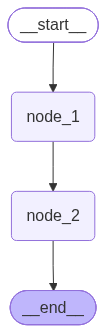

In [3]:
from langgraph.graph import StateGraph
from IPython.display import display, Image

workflow = StateGraph(MyState)
workflow.add_node("node_1", function_1)
workflow.add_node("node_2", function_2)
workflow.add_edge("node_1", "node_2")
workflow.set_entry_point("node_1")
workflow.set_finish_point("node_2")

app = workflow.compile()
app

In [4]:
app.invoke({"message": "Hello "})

Function 1 called with input: {'message': 'Hello '}
Function 2 called with input: {'message': 'Hello ', 'a': 'Hello  world'}


{'message': 'Hello ', 'a': 'Hello  world', 'b': 'Hello  world!'}

In [5]:
for output in app.stream({"message": "Hello "}):
    for key, value in output.items():
        print(f"{key}: {value}")

Function 1 called with input: {'message': 'Hello '}
node_1: {'a': 'Hello  world'}
Function 2 called with input: {'message': 'Hello ', 'a': 'Hello  world'}
node_2: {'b': 'Hello  world!'}


In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o-mini")

In [8]:
class MyState(TypedDict):
    messages: list

def function_1(state):
    response = model.invoke(state['messages'])
    
    return {"messages": [response]}

def function_2(state):
    print("Function 2 called with input:", state)
    return state

In [9]:
from langchain_core.messages import AIMessage, HumanMessage

workflow = StateGraph(MyState)
workflow.add_node("node_1", function_1)
workflow.add_node("node_2", function_2)
workflow.add_edge("node_1", "node_2")
workflow.set_entry_point("node_1")
workflow.set_finish_point("node_2")
app = workflow.compile()

app.invoke({"messages": [HumanMessage(content="Hello")]})

Function 2 called with input: {'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c881474fd1', 'id': 'chatcmpl-EHSnz8F385Kj1JimjrHg68klqqI14', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a04308-45e2-7fc1-bfdc-73392d5fc3f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detail

{'messages': [AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c881474fd1', 'id': 'chatcmpl-EHSnz8F385Kj1JimjrHg68klqqI14', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a04308-45e2-7fc1-bfdc-73392d5fc3f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [10]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper
import os
weather = OpenWeatherMapAPIWrapper()

C:\Users\localadmin\AppData\Local\Temp\ipykernel_8692\3622699175.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import OpenWeatherMapAPIWrapper


In [11]:
weather_data = weather.run("Bangalore")
print(weather_data)

In Bangalore, the current weather is as follows:
Detailed status: overcast clouds
Wind speed: 5.66 m/s, direction: 260°
Humidity: 67%
Temperature: 
  - Current: 27.79°C
  - High: 29.64°C
  - Low: 26.78°C
  - Feels like: 29.91°C
Rain: {}
Heat index: None
Cloud cover: 100%


In [12]:
class MyState(TypedDict):
    query: str
    city: str
    response: str

def function_1(state):
    prompt = "Your task is to provide only city name based on the query. " \
             "Just return the city name without any additional text. Following is the query: " + state['query']

    response = model.invoke(prompt)
    
    return {"city": response.content}

def function_2(state):
    response = weather.run(state['city'])
    return {"response": response}

def function_3(state):
    agent2_query = """Your task is to provide info concisely based on the
             user query and the available information from the internet.
            Following is the user query: """ + state['query'] + " Available information: " + state['response']
    response = model.invoke(agent2_query)
    return {"response": response.content}

In [13]:
workflow = StateGraph(MyState)
workflow.add_node("node_1", function_1)
workflow.add_node("node_2", function_2)
workflow.add_node("node_3", function_3)
workflow.add_edge("node_1", "node_2")
workflow.add_edge("node_2", "node_3")
workflow.set_entry_point("node_1")
workflow.set_finish_point("node_3")
app = workflow.compile()

app.invoke({"query": "What is the windspeed in Bangalore today?"})

{'query': 'What is the windspeed in Bangalore today?',
 'city': 'Bangalore',
 'response': 'The wind speed in Bangalore today is 5.66 m/s, coming from the direction of 260°.'}

In [14]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

In [15]:
def function_1(state):
    messages = state['messages']
    user_input = messages[-1]
    complete_query = "Your task is to provide only the city name based on the user query. " \
                     "Nothing more, just the city name mentioned. Following is the user query: " + user_input
    response = model.invoke(complete_query)
  
    return {"messages": [response.content]}

def function_2(state):
    messages = state['messages']
    agent_response = messages[-1]
    weather = OpenWeatherMapAPIWrapper()
    weather_data = weather.run(agent_response)
    return {"messages": [weather_data]}

def function_3(state):
    messages = state['messages']
    user_input = messages[0]
    available_info = messages[-1]
    agent2_query = """Your task is to provide info concisely based on the
             user query and the available information from the internet.
            Following is the user query: """ + user_input + " Available information: " + available_info
    response = model.invoke(agent2_query)
    return {"messages": [response.content]}

In [16]:
workflow = StateGraph(AgentState)
workflow.add_node("node_1", function_1)
workflow.add_node("node_2", function_2)
workflow.add_node("node_3", function_3)
workflow.add_edge("node_1", "node_2")  
workflow.add_edge("node_2", "node_3")
workflow.set_entry_point("node_1")
workflow.set_finish_point("node_3")
app = workflow.compile()

app.invoke({"messages": ["What is the temperature in Bangalore today?"]})

{'messages': ['What is the temperature in Bangalore today?',
  'Bangalore',
  'In Bangalore, the current weather is as follows:\nDetailed status: overcast clouds\nWind speed: 5.14 m/s, direction: 250°\nHumidity: 66%\nTemperature: \n  - Current: 27.72°C\n  - High: 29.64°C\n  - Low: 26.78°C\n  - Feels like: 29.68°C\nRain: {}\nHeat index: None\nCloud cover: 100%',
  'The current temperature in Bangalore is 27.72°C, with a high of 29.64°C and a low of 26.78°C. It feels like 29.68°C, and the weather is overcast with 100% cloud cover.']}

In [17]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    # messages: Annotated[Sequence[BaseMessage], operator.add]

In [18]:
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Siva")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='66576ebc-f4f5-4bc7-8969-2f490c39d3a0', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Siva', id='0a29eb04-c4df-4b8c-a231-bcc96498a421'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='cdbe1bad-439c-4f31-bcd7-4879fb5f64b8', tool_calls=[], invalid_tool_calls=[])]

In [19]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model", id="1"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Siva", id="2")
                   ]

# New message to add (same ID as existing message)
new_message = HumanMessage(content="I'm looking for information on whales, specifically", name="Siva", id="2")

# Test
add_messages(initial_messages, new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on whales, specifically", additional_kwargs={}, response_metadata={}, name='Siva', id='2')]

In [20]:
from langchain_core.messages import RemoveMessage

# Message list
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Siva", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Siva", id="4"))

# Isolate messages to delete (all except last 2)
delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]
print(delete_messages)

add_messages(messages, delete_messages)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]


[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Siva', id='4')]

In [21]:
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain_community.tools.openweathermap import OpenWeatherMapQueryRun
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [OpenWeatherMapQueryRun(), add, multiply, divide]

model = ChatOpenAI(temperature=0, streaming=True)
model = model.bind_tools(tools)

In [22]:
def function_1(state):
    messages = state['messages']

    response = model.invoke(messages)
    print("Response from function_1", response)
    return {"messages": [response]}

In [23]:
def where_to_go(state):
    messages = state['messages']
    last_message = messages[-1]
    print("Inside where to go=== ", last_message)

    if last_message.tool_calls:
        return "continue"
    else:
        return "end"

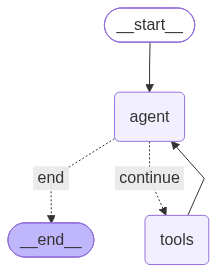

In [24]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(state_schema=AgentState)

workflow.add_node("agent", function_1)
workflow.add_node("tools", ToolNode(tools=tools))

workflow.add_conditional_edges("agent", where_to_go, {
    "continue": "tools",
    "end": END
})

workflow.add_edge('tools', 'agent')

workflow.set_entry_point("agent")

conn = sqlite3.connect("checkpoints.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)

app = workflow.compile(checkpointer=memory)

app

In [25]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

inputs = {"messages": [HumanMessage(content="what is the humidity in Chennai")]}
response = app.invoke(inputs, config)
response

Response from function_1 content='' additional_kwargs={} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'} id='lc_run--01a0430f-60b7-7ff0-8ea2-e1625eefdd9c' tool_calls=[{'name': 'open_weather_map', 'args': {'location': 'Chennai'}, 'id': 'call_2LFBaYue3uRYpFQ17xThgAZO', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 195, 'output_tokens': 16, 'total_tokens': 211, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
Inside where to go===  content='' additional_kwargs={} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'} id='lc_run--01a0430f-60b7-7ff0-8ea2-e1625eefdd9c' tool_calls=[{'name': 'open_weather_map', 'args': {'location': 'Chennai'}, 'id': 'call_2LFBaYue3uRYpFQ17xThgAZO', 'type': 'tool_call'}] invalid_tool_calls=[] usage

{'messages': [HumanMessage(content='what is the humidity in Chennai', additional_kwargs={}, response_metadata={}, id='9fb8c319-74e5-441d-b172-80a0d0de062c'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a0430f-60b7-7ff0-8ea2-e1625eefdd9c', tool_calls=[{'name': 'open_weather_map', 'args': {'location': 'Chennai'}, 'id': 'call_2LFBaYue3uRYpFQ17xThgAZO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 195, 'output_tokens': 16, 'total_tokens': 211, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  ToolMessage(content='In Chennai, the current weather is as follows:\nDetailed status: overcast clouds\nWind speed: 2.57 m/s, direction: 130°\nHumidity: 73%\nTemperature: \n  - Current: 31.8°C\n  - High: 32.99°C\n  - Low: 31.65°C\n  - Feels like: 38.8°C\

In [26]:
snapshot = app.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='what is the humidity in Chennai', additional_kwargs={}, response_metadata={}, id='9fb8c319-74e5-441d-b172-80a0d0de062c'), AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a0430f-60b7-7ff0-8ea2-e1625eefdd9c', tool_calls=[{'name': 'open_weather_map', 'args': {'location': 'Chennai'}, 'id': 'call_2LFBaYue3uRYpFQ17xThgAZO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 195, 'output_tokens': 16, 'total_tokens': 211, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), ToolMessage(content='In Chennai, the current weather is as follows:\nDetailed status: overcast clouds\nWind speed: 2.57 m/s, direction: 130°\nHumidity: 73%\nTemperature: \n  - Current: 31.8°C\n  - High: 32.99°C\n  - Low: 31.65°C\n  - Fe

In [27]:
user_input = "What is java language? "
config = {"configurable": {"thread_id": "15"}}
# The config is the **second positional argument** to stream() or invoke()!
events = app.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

What is java language? 
Response from function_1 content='Java is a high-level, object-oriented programming language developed by Sun Microsystems (now owned by Oracle). It is known for its platform independence, meaning that Java programs can run on any device that has a Java Virtual Machine (JVM) installed. Java is widely used for developing web applications, mobile applications, desktop applications, and enterprise software. It is also used in embedded systems, IoT devices, and scientific applications. Java is known for its simplicity, readability, and robustness.' additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'} id='lc_run--01a0430f-ddef-79c3-8790-a25ed2782e9f' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 195, 'output_tokens': 97, 'total_tokens': 292, 'input_token_details':

In [28]:
user_input = "What is 2+5 multiplied by 7? "
config = {"configurable": {"thread_id": "15"}}
# The config is the **second positional argument** to stream() or invoke()!
events = app.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

What is 2+5 multiplied by 7? 
Response from function_1 content='' additional_kwargs={} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'} id='lc_run--01a04310-21c3-7061-9100-bc0eb70463ab' tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 5}, 'id': 'call_Ial0t69H0Nu1SBNeC3bDpecH', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 311, 'output_tokens': 17, 'total_tokens': 328, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
Inside where to go===  content='' additional_kwargs={} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-3.5-turbo-0125', 'service_tier': 'default', 'model_provider': 'openai'} id='lc_run--01a04310-21c3-7061-9100-bc0eb70463ab' tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 5}, 'id': 'call_Ial0

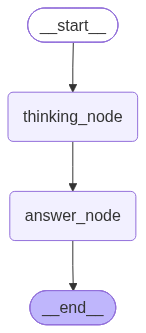

{'question': 'hi', 'answer': 'bye Siva', 'notes': '... his is name is Siva'}

In [31]:
from langgraph.graph import START


class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: OverallState):
    return {"answer": "bye", "notes": "... his is name is Siva"}

def answer_node(state: OverallState):
    return {"answer": "bye Siva"}

graph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question": "hi"})

C:\Users\localadmin\AppData\Local\Temp\ipykernel_8692\1002405036.py:18: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  graph = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\localadmin\AppData\Local\Temp\ipykernel_8692\1002405036.py:18: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  graph = StateGraph(OverallState, input=InputState, output=OutputState)


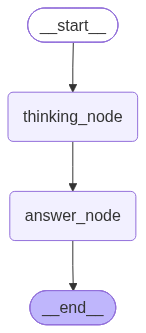

{'answer': 'bye Siva'}

In [32]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... his is name is siva"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Siva"}

graph = StateGraph(OverallState, input=InputState, output=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question": "hi"})